# ftir_37 — HIPS loading domain and nonlinear Fabs–TOR behavior

## tl;dr

High loading is an empirical problem, not just a literature caveat. In the shipped
SPARTAN HIPS batch, the fraction of samples below the calibration-set blank R1 range rises
from **<1% at low loading to ~32% in the highest-loading bin** (median Fabs ~47 Mm⁻¹).
In 148,476 quality-screened IMPROVE HIPS–TOR pairs, a quadratic Fabs model lowers
site-balanced, held-out-site RMSE by **9.9%** versus a linear model. Across 161 sites,
curvature is predominantly concave and fitting only the high-loading half shifts the
apparent linear intercept upward by a median **0.44 Mm⁻¹**. This supports a loading-driven
apparent-intercept mechanism, but it does not prove that it explains the full Addis offset:
the SPARTAN blank line is calibrated on unloaded filters and no independent Addis TOR EC is
present.

## Context & Methods

Two independent Davis sources are used: the shipped SPARTAN HIPS table for R1 blank-domain
coverage, and IMPROVE filters carrying both 633-nm HIPS Fabs and TOR EC/OC for the response
test. The nonlinear comparison is leakage-safe at the site level: each fold holds out whole
IMPROVE sites. Sites are inverse-frequency weighted during fitting, and the headline RMSE
gives every site equal weight.

### Key assumptions

- HIPS Fabs is Mm⁻¹; TOR EC/OC values in the local database are ng m⁻³ and are divided by
  1000.
- The first HIPS result is retained where a filter has duplicate result rows; the ledger
  reports that ambiguity.
- The 0.5–99.5% trim is a declared numerical-quality screen, not an outlier claim about a
  named sample.
- Curvature across IMPROVE is transferable evidence about the instrument/filter system,
  not a substitute for paired Addis quartz TOR.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, './scripts')
sys.path.insert(0, '../ftir_hips_chem/scripts')

from plotting import apply_default_style
from theory_test_suite import (
    curvature_analysis,
    davis_root,
    hips_blank_domain,
    load_improve_hips_tor_bridge,
)

apply_default_style()
ROOT = Path('.')
OUT = ROOT / 'output/tables/ftir37'
PLOTS = ROOT / 'output/plots/ftir37'
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
print('Davis source root:', davis_root())

Davis source root: /Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/Data/Davis Data


## Data

### Data quality and join coverage

The ledger makes the grain and join losses visible. The HIPS file contains repeated result
rows; the analysis grain after deduplication is one filter. HIPS is joined through the FTIR
catalog to site/date TOR EC and OC. Only positive, finite Fabs/EC/OC rows enter modeling.

In [2]:
bridge, join_ledger = load_improve_hips_tor_bridge()
hips_samples, loading_bins, hips_quality = hips_blank_domain()
display(join_ledger)
display(hips_quality)
display(loading_bins.round(3))

join_ledger.to_csv(OUT / 'improve_join_ledger.csv', index=False)
hips_quality.to_csv(OUT / 'spartan_hips_quality.csv', index=False)
loading_bins.to_csv(OUT / 'spartan_blank_domain_by_loading.csv', index=False)

,stage,rows,unique_filters,hips_duplicate_rows_all_occurrences,tor_duplicate_site_date_parameter_rows
0,HIPS fAbs rows,404603,379414,25226,0
1,HIPS first result per filter,379414,379414,25226,0
2,catalog match,379414,162250,25226,0
3,TOR EC+OC match,379414,160023,25226,0
4,positive finite analysis set,151843,151843,25226,0


,source_rows,sample_filters,blank_rows,calibration_sets_with_blanks,sample_blank_domain_coverage_pct,sample_outside_blank_domain_pct,hips_uncertainty_nonnull_pct
0,3963,3180,582,14,99.842767,15.754717,91.72956


,n,Fabs_median,Fabs_min,Fabs_max,below_blank_pct,outside_blank_pct,r1_position_median
0,579,3.165,-0.415,5.238,0.345,16.408,0.663
1,578,7.851,5.241,10.753,0.346,8.478,0.639
2,578,14.554,10.754,19.646,3.114,7.785,0.468
3,578,26.219,19.686,34.570,11.765,13.322,0.330
4,579,47.216,34.607,225.518,32.124,32.815,0.111


## Results

### Held-out-site curvature test

All models include log(OC/EC) and an EC×composition term where applicable. The comparison
is predictive: if curvature is merely an in-sample artifact, it should not improve on whole
sites excluded from fitting.

In [3]:
cv, curves, site_effects, site_tests = curvature_analysis(bridge)
display(cv.round(4))
display(site_tests.round(5))
cv.to_csv(OUT / 'heldout_site_model_comparison.csv', index=False)
curves.to_csv(OUT / 'fitted_curves_at_median_ocec.csv', index=False)
site_effects.to_csv(OUT / 'within_site_curvature_and_intercepts.csv', index=False)
site_tests.to_csv(OUT / 'within_site_signed_rank_tests.csv', index=False)

,model,n,sites,pooled_RMSE_Mm1,site_balanced_RMSE_Mm1,pooled_R2,site_balanced_RMSE_change_pct_vs_linear
0,linear,148476,181,0.8045,0.9238,0.8045,0.0000
1,quadratic,148476,181,0.7282,0.8322,0.8411,-9.9154
2,spline,148476,181,0.7488,0.8544,0.8324,-7.5178


,test,n_sites,median_effect,wilcoxon_p
0,within-site quadratic coefficient differs from...,161,-0.03383,0.0
1,high-minus-low loading-range intercept differs...,161,0.43756,0.0


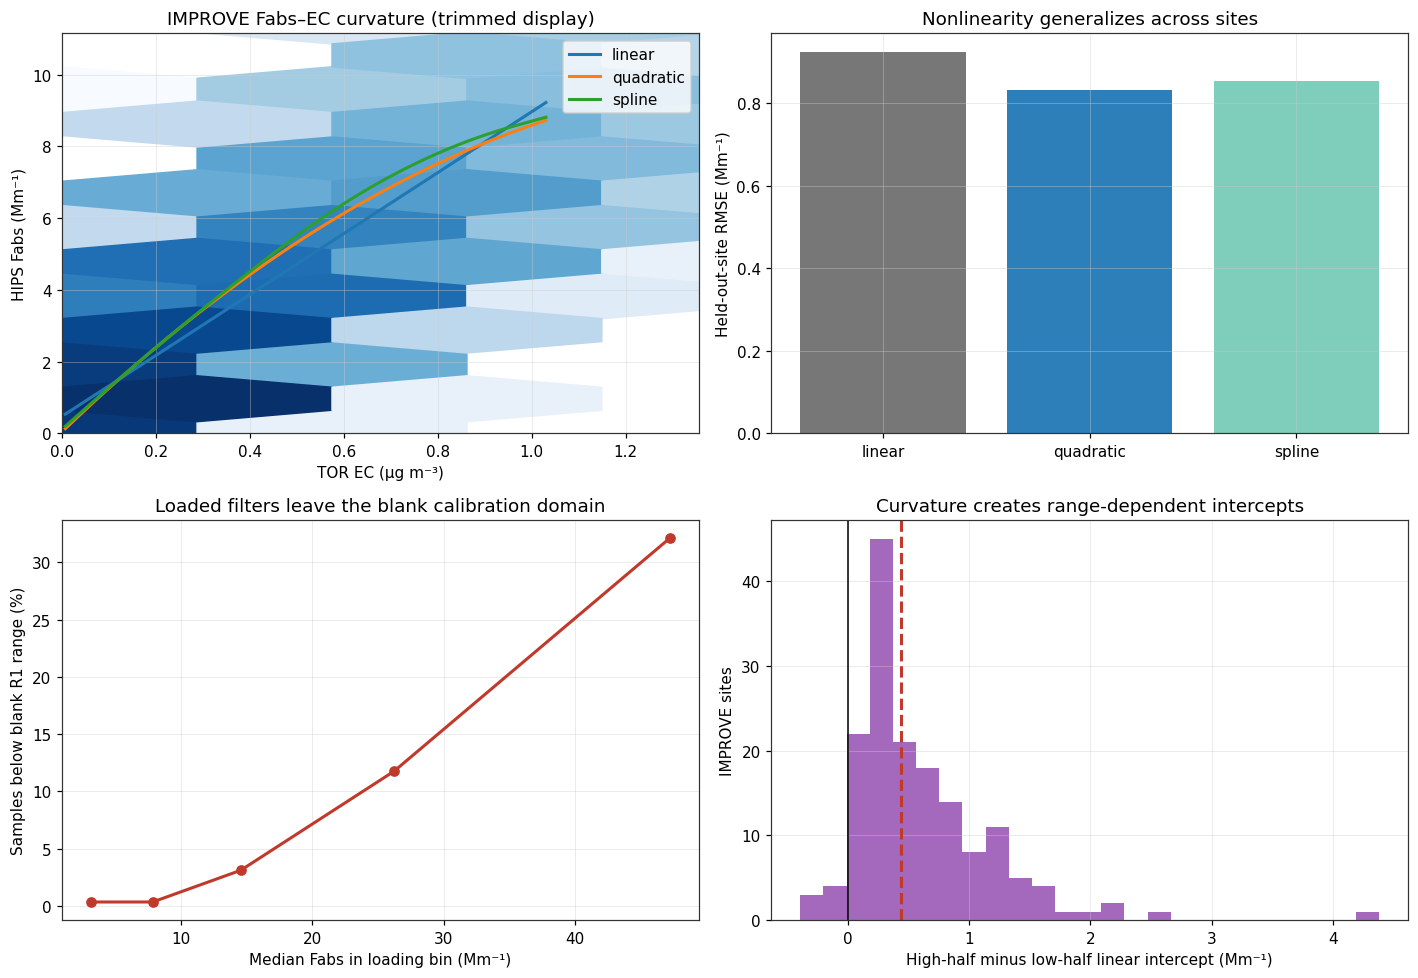

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sample = bridge.sample(min(25000, len(bridge)), random_state=20260901)
axes[0, 0].hexbin(sample['EC_ugm3'], sample['Fabs_Mm1'], gridsize=55,
                  mincnt=1, bins='log', cmap='Blues')
for model, group in curves.groupby('model'):
    axes[0, 0].plot(group['EC_ugm3'], group['predicted_Fabs'], lw=2, label=model)
axes[0, 0].set(xlabel='TOR EC (µg m⁻³)', ylabel='HIPS Fabs (Mm⁻¹)',
               title='IMPROVE Fabs–EC curvature (trimmed display)')
axes[0, 0].set_xlim(0, bridge['EC_ugm3'].quantile(.99))
axes[0, 0].set_ylim(0, bridge['Fabs_Mm1'].quantile(.99))
axes[0, 0].legend()

axes[0, 1].bar(cv['model'], cv['site_balanced_RMSE_Mm1'], color=['#777777', '#2C7FB8', '#7FCDBB'])
axes[0, 1].set(ylabel='Held-out-site RMSE (Mm⁻¹)', title='Nonlinearity generalizes across sites')

axes[1, 0].plot(loading_bins['Fabs_median'], loading_bins['below_blank_pct'],
                marker='o', lw=2, color='#C0392B')
axes[1, 0].set(xlabel='Median Fabs in loading bin (Mm⁻¹)',
               ylabel='Samples below blank R1 range (%)',
               title='Loaded filters leave the blank calibration domain')

axes[1, 1].hist(site_effects['high_minus_low_intercept_Mm1'], bins=25,
                color='#8E44AD', alpha=.8)
axes[1, 1].axvline(0, color='black', lw=1)
axes[1, 1].axvline(site_effects['high_minus_low_intercept_Mm1'].median(),
                   color='#C0392B', ls='--', lw=2)
axes[1, 1].set(xlabel='High-half minus low-half linear intercept (Mm⁻¹)',
               ylabel='IMPROVE sites', title='Curvature creates range-dependent intercepts')

fig.tight_layout()
fig.savefig(PLOTS / 'hips_loading_and_curvature.png', bbox_inches='tight')
plt.show()

## Takeaways

- **Supported:** HIPS/PTFE behavior changes with loading, and a linear Fabs–EC law is
  inadequate across the Davis IMPROVE archive.
- **Supported:** nonlinear behavior can generate apparent intercepts whose value depends on
  the loading range used for the regression.
- **Not closed:** the analysis cannot apportion the Addis offset between filter-loading
  physics, non-EC aerosol absorption, and FTIR calibration error because Addis lacks an
  independent TOR EC axis.
- **Design consequence:** the quartz campaign must span the observed Fabs range and retain
  raw HIPS R/T diagnostics; a low-loading-only comparison would miss the mechanism.